# Assignment 
# Ensemble Learning Q&A

## Theory Base Questions

1. Can we use Bagging for regression problems? 
- Yes, Bagging (Bootstrap Aggregating) is highly effective for regression problems. It works by training multiple models (typically decision trees) on random subsets of the data and averaging their predictions to reduce variance and prevent overfitting. 

2. What is the difference between multiple model training and single model training? 
- Single model training uses one model for all data, offering simplicity and lower computational costs, while multiple model training (ensemble or specialized) uses several models to improve accuracy, handling diverse data or specialized tasks better. Multiple models provide better performance, but higher complexity and maintenance.

3. Explain the concept of feature randomness in Random Forest.
- Feature randomness, also known as feature bagging or “the random subspace method”, generates a random subset of features, which ensures low correlation among decision trees. This deliberate injection of randomness helps to prevent the trees from becoming too similar and reduces the risk of overfitting, leading to a more robust and accurate overall model.

4. What is OOB (Out-of-Bag) Score? 
- OOB (out-of-bag) score is a performance metric for a machine learning model, specifically for ensemble models such as random forests. It is calculated using the samples that are not used in the training of the model, which is called out-of-bag samples. These samples are used to provide an unbiased estimate of the model's performance, which is known as the OOB score.

5. How can you measure the importance of features in a Random Forest model? 
- Feature importance in Random Forest is primarily calculated using Mean Decrease in Impurity (MDI), also known as Gini Importance. It measures how much each feature reduces the impurity (Gini impurity for classification, variance for regression) across all decision trees, weighted by the number of samples affected at each split.

6. Explain the working principle of a Bagging Classifier?
- Bagging or Bootstrap Aggregating, works by training multiple base models independently and in parallel on different random subsets of the training data. These subsets are created using bootstrap sampling, where data points are randomly selected with replacement, allowing some samples to appear multiple times while others may be excluded. Working of Bagging Classifier:
  - Bootstrap Sampling: From the original dataset, multiple training subsets are created by sampling with replacement. This generates diverse data views, reducing overfitting and improving model generalization.
  - Base Model Training: Each bootstrap sample trains an independent base learner (e.g., decision trees, SVMs, neural networks). These “weak learners” may not perform well alone but contribute to ensemble strength. Training happens in parallel, making bagging efficient.
  - Aggregation: Once trained, each base model generates predictions on new data. For classification, predictions are combined via majority voting; for regression, predictions are averaged to produce the final outcome.
  - Out-of-Bag (OOB) Evaluation: Samples excluded from a particular bootstrap subset (called out-of-bag samples) provide a natural validation set for that base model. OOB evaluation offers an unbiased performance estimate without additional cross-validation.

7. How do you evaluate a Bagging Classifier’s performance?
- Evaluating a Bagging Classifier involves measuring its predictive power on unseen data using metrics like accuracy, F1-score, precision, and recall. Key steps include splitting data into training/testing sets, using OOB (Out-of-Bag) samples for validation, and comparing ensemble accuracy against individual base learner performance.

8. How does a Bagging Regressor work?
- A Bagging Regressor (Bootstrap Aggregating Regressor) is an ensemble machine learning algorithm designed to improve the stability and accuracy of regression models, primarily by reducing variance and preventing overfitting. It works by training multiple base models (typically Decision Tree Regressors) independently in parallel on different random subsets of the training data and then averaging their predictions to produce a final, robust prediction.

9. What is the main advantage of ensemble techniques?
- The main advantage of ensemble techniques is significantly improved predictive performance and accuracy compared to any single model. By combining multiple models (often called "weak learners"), ensemble methods; such as Bagging and Boosting, effectively reduce variance, mitigate overfitting, and produce more stable, robust predictions on complex, noisy datasets.

10. What is the main challenge of ensemble methods?
- The main challenges of ensemble methods are high computational costs (training/inference time), lack of interpretability ("black box" nature), and increased complexity in deployment and maintenance. Combining multiple models often requires significant resources and makes explaining individual decisions difficult.

11. Explain the key idea behind ensemble techniques.
- The key idea behind ensemble techniques is to combine multiple individual machine learning models—often called "weak learners"—to create a single, superior "strong learner". By aggregating predictions from diverse models, ensemble methods reduce variance, decrease bias, and improve overall accuracy, mitigating the risk of relying on one model that may overfit or perform poorly.

12. What is a Random Forest Classifier?
- The random forest classifier is an ensemble-based supervised learning algorithm that aggregates multiple decision trees, each trained on random samples of the data and a random subset of features when splitting nodes, to improve predictive accuracy and robustness in classification and regression tasks. 

13. What are the main types of ensemble techniques?
- Ensemble techniques in machine learning combine multiple models to enhance predictive performance, reduce variance, or reduce bias. The three main types are bagging (parallel training to reduce variance), boosting (sequential training to reduce bias), and stacking (combining models with a meta-learner).

14. What is ensemble learning in machine learning?
- Ensemble learning is a method where we use many small models instead of just one. Each of these models may not be very strong on its own, but when we put their results together, we get a better and more accurate answer. It's like asking a group of people for advice instead of just one person—each one might be a little wrong, but together, they usually give a better answer.

15. When should we avoid using ensemble methods?
- Ensemble methods should be avoided when model interpretability is crucial (e.g., healthcare, finance), as they act as "black boxes". They are also unsuitable when computational resources, training time, or inference latency are constrained, or when a simple model already provides sufficient accuracy, making the added complexity and potential overfitting not worth the minor performance gains.  

16. How does Bagging help in reducing overfitting?
- Bagging (Bootstrap Aggregating) reduces overfitting by training multiple models (typically decision trees) in parallel on different random subsets of the data—sampled with replacement—and averaging their predictions. This process lowers the model's overall variance and prevents it from becoming too dependent on noise in the training set. 
    
17. Why is Random Forest better than a single Decision Tree?
- Random Forest is superior to a single Decision Tree primarily because it reduces overfitting and high variance by aggregating predictions from multiple trees (ensemble learning). It is more robust to outliers and noise in data, leading to higher accuracy and better generalization on unseen data. If interpretability and transparency are important, Decision Tree may be more suitable. However, if the data is complex or contains a lot of noise, Random Forest may be a better choice due to its robustness and ability to handle noisy data.
  
18. What is the role of bootstrap sampling in Bagging?
- Bootstrap sampling in bagging (Bootstrap Aggregating) creates multiple diverse, overlapping subsets from the original dataset by sampling with replacement. This process introduces variance among the base models—typically high-variance models like decision trees—reducing overall model overfitting and improving prediction stability through independent training and aggregation.

19. What are some real-world applications of ensemble techniques?
- Key real-world applications include financial fraud detection, credit scoring, customer churn prediction, medical diagnostics, and recommender systems.

20. What is the difference between Bagging and Boosting?
- Bagging and Boosting are both ensemble learning techniques used to improve model performance by combining multiple models. The main difference is that:
  - Bagging reduces variance by training models independently.
  - Boosting reduces bias by training models sequentially, focusing on previous errors.

## Practical Questions


In [1]:
# 21. Train a Bagging Classifier using Decision Trees on a sample dataset and print model accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

base_model = DecisionTreeClassifier()

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred = bagging_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [2]:
# 22. Train a Bagging Regressor using Decision Trees and evaluate using Mean Squared Error (MSE).

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

base_model = DecisionTreeRegressor()

bagging_model = BaggingRegressor(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred = bagging_model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 0.25787382250585034


In [3]:
# 23.Train a Random Forest Classifier on the Breast Cancer dataset and print feature importance scores.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_

print("Feature Importances:\n")
for name, score in zip(feature_names, importances):
    print(f"{name}: {score:.4f}")

Feature Importances:

mean radius: 0.0323
mean texture: 0.0111
mean perimeter: 0.0601
mean area: 0.0538
mean smoothness: 0.0062
mean compactness: 0.0092
mean concavity: 0.0806
mean concave points: 0.1419
mean symmetry: 0.0033
mean fractal dimension: 0.0031
radius error: 0.0164
texture error: 0.0032
perimeter error: 0.0118
area error: 0.0295
smoothness error: 0.0059
compactness error: 0.0046
concavity error: 0.0058
concave points error: 0.0034
symmetry error: 0.0040
fractal dimension error: 0.0071
worst radius: 0.0780
worst texture: 0.0188
worst perimeter: 0.0743
worst area: 0.1182
worst smoothness: 0.0118
worst compactness: 0.0175
worst concavity: 0.0411
worst concave points: 0.1271
worst symmetry: 0.0129
worst fractal dimension: 0.0069


In [4]:
# 24.Train a Random Forest Regressor and compare its performance with a single Decision Tree.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

dt_mse = mean_squared_error(y_test, dt_pred)
rf_mse = mean_squared_error(y_test, rf_pred)

print("Decision Tree MSE:", dt_mse)
print("Random Forest MSE:", rf_mse)

Decision Tree MSE: 0.5280096503174904
Random Forest MSE: 0.25650512920799395


In [5]:
# 25. Compute the Out-of-Bag (OOB) Score for a Random Forest Classifier.

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier

data = load_breast_cancer()
X = data.data
y = data.target

model = RandomForestClassifier(
    n_estimators=100,
    oob_score=True,      
    random_state=42
)

model.fit(X, y)

print("OOB Score:", model.oob_score_)

OOB Score: 0.961335676625659


In [6]:
# 26.Train a Bagging Classifier using SVM as a base estimator and print accuracy.

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

data = load_iris()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

base_model = SVC(kernel='rbf', probability=True)

bagging_model = BaggingClassifier(
    estimator=base_model,
    n_estimators=10,
    random_state=42
)

bagging_model.fit(X_train, y_train)

y_pred = bagging_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 1.0


In [7]:
# 27. Train a Random Forest Classifier with different numbers of trees and compare accuracy.
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

tree_counts = [10, 50, 100, 200]

for n in tree_counts:
    model = RandomForestClassifier(n_estimators=n, random_state=42)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Number of Trees: {n} → Accuracy: {acc:.4f}")

Number of Trees: 10 → Accuracy: 0.9649
Number of Trees: 50 → Accuracy: 0.9708
Number of Trees: 100 → Accuracy: 0.9708
Number of Trees: 200 → Accuracy: 0.9708


In [9]:
# 28.Train a Bagging Classifier using Logistic Regression as a base estimator and print AUC score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

base_model = LogisticRegression(max_iter=5000)

model = BaggingClassifier(
    estimator=base_model,
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc)

AUC Score: 0.998236331569665


In [10]:
# 29. Train a Random Forest Regressor and analyze feature importance scores.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

data = fetch_california_housing()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importance_df)

      Feature  Importance
0      MedInc    0.526011
5    AveOccup    0.138220
7   Longitude    0.086124
6    Latitude    0.086086
1    HouseAge    0.054654
2    AveRooms    0.047188
4  Population    0.031722
3   AveBedrms    0.029995


In [11]:
# 30.Train an ensemble model using both Bagging and Random Forest and compare accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

bagging_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)

bagging_pred = bagging_model.predict(X_test)
rf_pred = rf_model.predict(X_test)

bagging_acc = accuracy_score(y_test, bagging_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Bagging Accuracy:", bagging_acc)
print("Random Forest Accuracy:", rf_acc)

Bagging Accuracy: 0.9590643274853801
Random Forest Accuracy: 0.9707602339181286


In [12]:
# 31.Train a Random Forest Classifier and tune hyperparameters using GridSearchCV.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Test Accuracy:", accuracy)

Best Parameters: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
Test Accuracy: 0.9649122807017544


In [1]:
# 32.Train a Bagging Regressor with different numbers of base estimators and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

estimators_list = [10, 50, 100, 200]

for n in estimators_list:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=n,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"Estimators: {n} → MSE: {mse:.4f}")

Estimators: 10 → MSE: 0.2862
Estimators: 50 → MSE: 0.2579
Estimators: 100 → MSE: 0.2568
Estimators: 200 → MSE: 0.2542


In [2]:
# 33. Train a Random Forest Classifier and analyze misclassified samples.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

X_train, X_test, y_train, y_test = train_test_split(
    df.drop('target', axis=1),
    df['target'],
    test_size=0.3,
    random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

misclassified = X_test[y_test != y_pred]

print("\nNumber of misclassified samples:", len(misclassified))

print("\nMisclassified samples:")
print(misclassified.head())

comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

print("\nComparison (Actual vs Predicted):")
print(comparison[y_test != y_pred].head())

Accuracy: 0.9707602339181286

Number of misclassified samples: 5

Misclassified samples:
     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
81         13.34         15.86           86.49      520.0          0.10780   
73         13.80         15.79           90.43      584.1          0.10070   
255        13.96         17.05           91.43      602.4          0.10960   
86         14.48         21.46           94.25      648.2          0.09444   
414        15.13         29.81           96.71      719.5          0.08320   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
81            0.15350         0.11690              0.06987         0.1942   
73            0.12800         0.07789              0.05069         0.1662   
255           0.12790         0.09789              0.05246         0.1908   
86            0.09947         0.12040              0.04938         0.2075   
414           0.04605         0.04686              0.0273

In [3]:
# 34. Train a Bagging Classifier and compare its performance with a single Decision Tree Classifier.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

bagging_model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
bagging_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)
bagging_pred = bagging_model.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)
bagging_acc = accuracy_score(y_test, bagging_pred)

print("Decision Tree Accuracy:", dt_acc)
print("Bagging Classifier Accuracy:", bagging_acc)

Decision Tree Accuracy: 0.9415204678362573
Bagging Classifier Accuracy: 0.9590643274853801


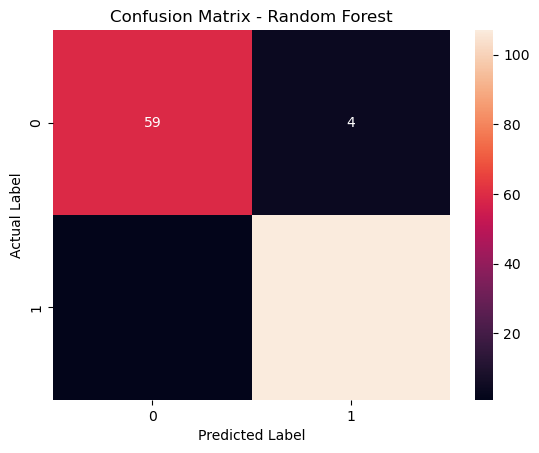

In [4]:
# 35. Train a Random Forest Classifier and visualize the confusion matrix.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [5]:
# 36. Train a Stacking Classifier using Decision Trees, SVM, and Logistic Regression, and compare accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

estimators = [
    ('dt', DecisionTreeClassifier()),
    ('svm', SVC(probability=True)),
    ('lr', LogisticRegression(max_iter=5000))
]

stacking_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking_model.fit(X_train, y_train)

y_pred_stack = stacking_model.predict(X_test)

stack_acc = accuracy_score(y_test, y_pred_stack)
print("Stacking Classifier Accuracy:", stack_acc)

for name, model in estimators:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name.upper()} Accuracy:", acc)

Stacking Classifier Accuracy: 0.9707602339181286
DT Accuracy: 0.9181286549707602
SVM Accuracy: 0.935672514619883
LR Accuracy: 0.9766081871345029


In [6]:
# 37. Train a Random Forest Classifier and print the top 5 most important features.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import pandas as pd

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

top5 = feature_importance_df.sort_values(by='Importance', ascending=False).head(5)

print("Top 5 Important Features:")
print(top5)

Top 5 Important Features:
                 Feature  Importance
7    mean concave points    0.141934
27  worst concave points    0.127136
23            worst area    0.118217
6         mean concavity    0.080557
20          worst radius    0.077975


In [7]:
# 38. Train a Bagging Classifier and evaluate performance using Precision, Recall, and F1-score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

report = classification_report(y_test, y_pred)

print("Classification Report:\n")
print(report)

Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [8]:
# 39.Train a Random Forest Classifier and analyze the effect of max_depth on accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

depths = [2, 4, 6, 8, 10, None]

for depth in depths:
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    
    print(f"max_depth = {depth} → Accuracy: {acc:.4f}")

max_depth = 2 → Accuracy: 0.9532
max_depth = 4 → Accuracy: 0.9708
max_depth = 6 → Accuracy: 0.9649
max_depth = 8 → Accuracy: 0.9708
max_depth = 10 → Accuracy: 0.9708
max_depth = None → Accuracy: 0.9708


In [9]:
# 40.Train a Bagging Regressor using different base estimators (DecisionTree and KNeighbors) and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

bagging_dt = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=50,
    random_state=42
)
bagging_dt.fit(X_train, y_train)
y_pred_dt = bagging_dt.predict(X_test)
mse_dt = mean_squared_error(y_test, y_pred_dt)

bagging_knn = BaggingRegressor(
    estimator=KNeighborsRegressor(),
    n_estimators=50,
    random_state=42
)
bagging_knn.fit(X_train, y_train)
y_pred_knn = bagging_knn.predict(X_test)
mse_knn = mean_squared_error(y_test, y_pred_knn)

print("Bagging (Decision Tree) MSE:", mse_dt)
print("Bagging (KNN) MSE:", mse_knn)

Bagging (Decision Tree) MSE: 0.25787382250585034
Bagging (KNN) MSE: 1.1020902555745289


In [10]:
# 41.Train a Random Forest Classifier and evaluate its performance using ROC-AUC Score.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.9968400940623163


In [11]:
# 42. Train a Bagging Classifier and evaluate its performance using cross-validation.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

data = load_breast_cancer()
X = data.data
y = data.target

model = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100,
    random_state=42
)

scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean Accuracy:", scores.mean())
print("Standard Deviation:", scores.std())

Cross-validation scores: [0.89473684 0.93859649 0.99122807 0.96491228 1.        ]
Mean Accuracy: 0.9578947368421054
Standard Deviation: 0.03819568606504778


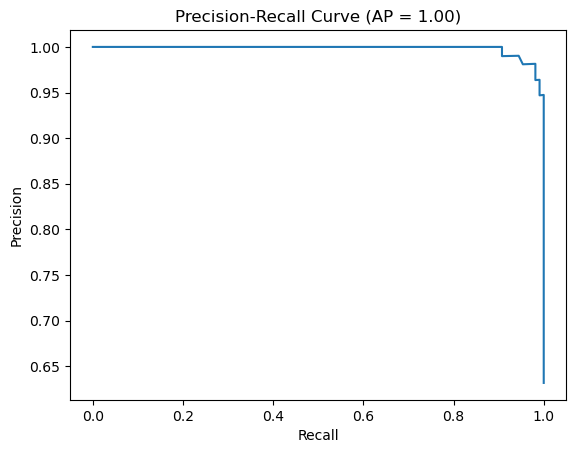

In [12]:
# 43. Train a Random Forest Classifier and plot the Precision-Recall curve.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_scores = model.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

ap_score = average_precision_score(y_test, y_scores)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision-Recall Curve (AP = {ap_score:.2f})")
plt.show()

In [13]:
# 44. Train a Stacking Classifier with Random Forest and Logistic Regression and compare accuracy.

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

estimators = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=5000))
]

stack_model = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stack_model.fit(X_train, y_train)

y_pred_stack = stack_model.predict(X_test)
stack_acc = accuracy_score(y_test, y_pred_stack)

print("Stacking Classifier Accuracy:", stack_acc)

for name, model in estimators:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name.upper()} Accuracy:", acc)

Stacking Classifier Accuracy: 0.9707602339181286
RF Accuracy: 0.9707602339181286
LR Accuracy: 0.9766081871345029


In [14]:
# 45. Train a Bagging Regressor with different levels of bootstrap samples and compare performance.

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

data = fetch_california_housing()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

sample_sizes = [0.5, 0.7, 0.9, 1.0]

for sample in sample_sizes:
    model = BaggingRegressor(
        estimator=DecisionTreeRegressor(),
        n_estimators=100,
        max_samples=sample,   # fraction of training data used
        bootstrap=True,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"max_samples = {sample} → MSE: {mse:.4f}")

max_samples = 0.5 → MSE: 0.2626
max_samples = 0.7 → MSE: 0.2585
max_samples = 0.9 → MSE: 0.2580
max_samples = 1.0 → MSE: 0.2568
